# Chapter 67 — Scaling and Shifting

> **Prerequisites:** ch066 (Function Transformations)
>
> **You will learn:**
> - Apply and interpret linear transformations of variables
> - Understand z-score, min-max, and robust scaling
> - Implement affine transformations on data
> - Connect to feature preprocessing in ML
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

**Scaling** multiplies values by a constant. **Shifting** adds a constant. Together, they form an **affine transformation** of the variable:

y = a·x + b

where a is the scale factor and b is the shift.

Applied to functions: if we replace x with ax + b, we get a transformed function.
Applied to data: if we replace each data point xᵢ with a·xᵢ + b, we re-scale the distribution.

**Common ML transformations:**
- **Z-score (standardization):** y = (x - μ)/σ — centers at 0, scales to unit variance
- **Min-max scaling:** y = (x - min)/(max - min) — maps to [0, 1]
- **Robust scaling:** y = (x - median)/IQR — resistant to outliers

All three are affine transformations: y = ax + b with different choices of a and b.

*(These are the function transformations from ch066 applied to data.)*

---

## 2. Intuition & Mental Models

**Physical analogy:** Temperature conversion. Celsius to Fahrenheit is F = 1.8·C + 32 — an affine transformation. The scale factor (1.8) changes the unit size; the shift (32) accounts for the different zero point.

**Computational analogy:** NumPy broadcasting. `(x - mean) / std` applied to an array transforms every element identically. The array is treated as a sampled function and the transformation is applied element-wise.

---

## 3. Visualization

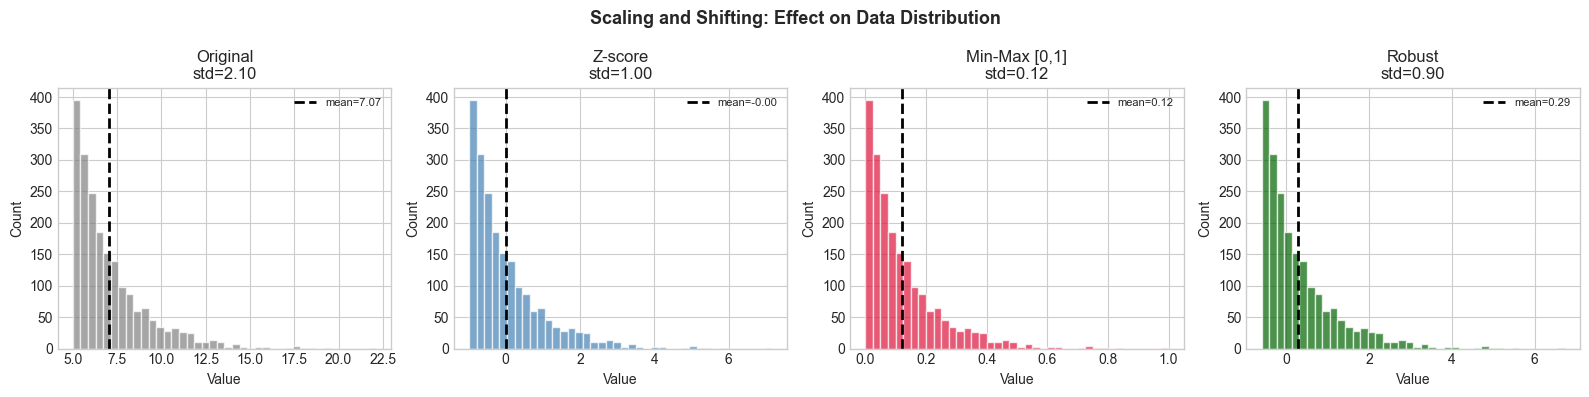

In [1]:
# --- Visualization: Effect of scaling and shifting on distributions ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(0)
x = np.random.exponential(2, 2000) + 5  # skewed, non-centered

def z_score(x): return (x - x.mean()) / x.std()
def minmax(x): return (x - x.min()) / (x.max() - x.min())
def robust(x):
    med = np.median(x)
    iqr = np.percentile(x, 75) - np.percentile(x, 25)
    return (x - med) / iqr

transforms = {'Original': x, 'Z-score': z_score(x),
              'Min-Max [0,1]': minmax(x), 'Robust': robust(x)}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colors = ['gray', 'steelblue', 'crimson', 'darkgreen']

for ax, (name, data), color in zip(axes, transforms.items(), colors):
    ax.hist(data, bins=40, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(np.mean(data), color='black', linestyle='--', linewidth=2, label=f'mean={np.mean(data):.2f}')
    ax.set_title(f'{name}\nstd={np.std(data):.2f}')
    ax.set_xlabel('Value'); ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.suptitle('Scaling and Shifting: Effect on Data Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 5. Python Implementation

In [2]:
# --- Implementation: Scaler class ---
import numpy as np

class StandardScaler:
    """Z-score normalization: y = (x - mean) / std."""
    
    def __init__(self):
        self.mean_ = None
        self.std_ = None
    
    def fit(self, x):
        """Compute mean and std from training data."""
        x = np.asarray(x, dtype=float)
        self.mean_ = x.mean(axis=0)
        self.std_ = x.std(axis=0) + 1e-8
        return self
    
    def transform(self, x):
        """Apply z-score transform."""
        return (np.asarray(x, dtype=float) - self.mean_) / self.std_
    
    def inverse_transform(self, y):
        """Undo z-score transform."""
        return y * self.std_ + self.mean_

# Demo
np.random.seed(1)
train = np.random.exponential(3, 500) + 10
test = np.random.exponential(3, 100) + 10

scaler = StandardScaler().fit(train)
train_scaled = scaler.transform(train)
test_scaled = scaler.transform(test)

print(f"Train - mean: {train.mean():.2f}, std: {train.std():.2f}")
print(f"Scaled - mean: {train_scaled.mean():.4f}, std: {train_scaled.std():.4f}")
print(f"Test scaled - mean: {test_scaled.mean():.4f}")
print(f"Recover original: max error = {np.max(np.abs(scaler.inverse_transform(train_scaled) - train)):.2e}")

Train - mean: 13.08, std: 2.94
Scaled - mean: 0.0000, std: 1.0000
Test scaled - mean: -0.1163
Recover original: max error = 0.00e+00


---

## 6. Experiments

**Experiment 1:** Apply z-scoring to data from three different distributions (normal, exponential, uniform). Does z-scoring change the SHAPE of the distribution? (No — only location and scale change.)

**Experiment 2:** Fit a StandardScaler on training data and apply to test data that has a different mean. What happens? This is 'distribution shift' — a common ML failure mode.

---

## 7. Exercises

**Easy 1.** Convert 100°C, 0°C, -40°C to Fahrenheit. Show this is an affine transformation. *(Expected: 212, 32, -40)*

**Easy 2.** If x has mean 5 and std 2, what is the mean and std of z = (x - 5)/2? *(Expected: mean=0, std=1)*

**Medium 1.** Implement MinMaxScaler with fit/transform/inverse_transform methods, mirroring StandardScaler above.

**Medium 2.** A dataset has outliers. Compare z-score vs robust scaling: generate normal data with 5% outliers (very large values). Show which scaler is more affected by outliers.

**Hard.** Prove that z-score normalization followed by a linear model is equivalent to the original data with a different linear model. Specifically: if you fit y = wx + b on z-scored data, what are the equivalent weights w', b' on the original data?

---

## 9. Chapter Summary & Connections

- Scaling (multiply) and shifting (add) are affine transformations y = ax + b
- Z-score: a=1/σ, b=-μ/σ; Min-max: a=1/(max-min), b=-min/(max-min)
- Scaling never changes the distribution shape — only location and spread
- Always fit scalers on training data only; apply the same transform to test data

**Forward connections:**
- ch277 (Bias and Variance) shows that improper scaling can inflate variance estimates
- ch281 (Regression) requires feature scaling for numerical stability of optimization